# thesis codebase walkthrough




**Evaluating SHAP explanation stability in optimized NLP models for Alzheimer’s risk classification from speech transcripts**

## What this notebook let you see


It is meant for a **code-level discussion** not as an replacement for the full code script `run_pipeline.py`.

---

## Important limitation

> **The convenience cohort is imbalanced; numbers here validate the *pipeline* and analysis design, not final challenge claims.**


### Setup (run first)

The cells below assume the notebook kernel’s current working directory is the **project root** (`Thesis/`). If you open the notebook from elsewhere, adjust `PROJECT_ROOT`.


In [1]:
import sys
from pathlib import Path
from IPython.display import display, Markdown

# Project root (parent of notebooks/ if kernel cwd is notebooks/)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("OUTPUT_DIR   =", OUTPUT_DIR)


PROJECT_ROOT = C:\Users\Yazan\Thesis
OUTPUT_DIR   = C:\Users\Yazan\Thesis\outputs


---

## 2. Project architecture overview

End-to-end orchestration lives in **`run_pipeline.py`**. Domain logic is split under **`src/`** so each concern can be tested and cited in the thesis.

| Module | Role |
|--------|------|
| `src/config.py` | Paths (`DATA_DIR`, `OUTPUT_DIR`), feature column order, CV/SHAP seeds, label-mode flags. |
| `src/data_loading.py` | Resolve dataset root; load labels (`participant_labels.csv` **or** augmented `Data_AUG*.csv`). |
| `src/preprocessing.py` | Load Cookie Theft transcripts; extract participant lines; clean text; QC flags. |
| `src/feature_extraction.py` | spaCy + SBERT features: TTR, fillers, clause length, coherence, POS ratios. |
| `src/modeling.py` | Baseline pipelines (LR / RF / SVM × `class_weight`); stratified CV; imbalance-aware metrics. |
| `src/optimization.py` | `GridSearchCV` per model family; refitted estimators for SHAP/stability. |
| `src/explainability.py` | SHAP: LinearExplainer (LR), TreeExplainer (RF), KernelExplainer (SVM). |
| `src/stability.py` | SHAP stability across CV folds & bootstraps; baseline vs optimized global profile agreement. |
| `src/visualization.py` | Bar plots for performance / stability / AUROC–stability trade-off. |

Together: **labels + transcripts → features → models → SHAP → stability → CSV + figures**.


## 3. Pipeline diagram (conceptual)

The next cell draws a simple flowchart. The same flow is implemented sequentially in `run_pipeline.py`.


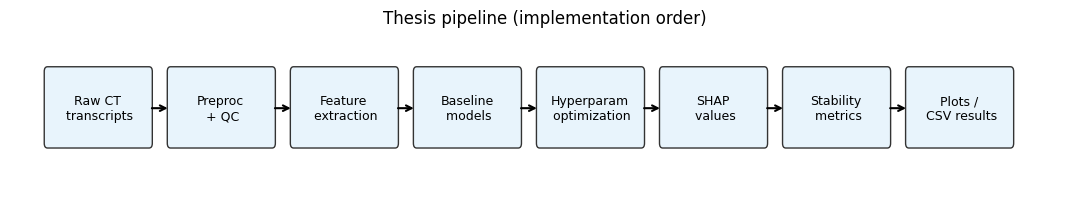

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 2.2))
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
ax.axis("off")
boxes = [
    "Raw CT\n transcripts",
    "Preproc\n + QC",
    "Feature\n extraction",
    "Baseline\n models",
    "Hyperparam\n optimization",
    "SHAP\n values",
    "Stability\n metrics",
    "Plots /\n CSV results",
]
xs = [0.35 + i * 1.15 for i in range(len(boxes))]
for i, t in enumerate(boxes):
    x = xs[i]
    ax.add_patch(
        mpatches.FancyBboxPatch(
            (x, 0.35), 0.95, 0.45, boxstyle="round,pad=0.03", ec="#333", fc="#e8f4fc"
        )
    )
    ax.text(x + 0.47, 0.57, t, ha="center", va="center", fontsize=9)
    if i > 0:
        ax.annotate(
            "",
            xy=(x, 0.57),
            xytext=(x - 0.2, 0.57),
            arrowprops=dict(arrowstyle="->", lw=1.5),
        )
ax.set_title("Thesis pipeline (implementation order)", fontsize=12, pad=12)
plt.tight_layout()
plt.show()


---

## 4. Dataset inspection

We resolve the data directory the same way as `src.config`, then show **label source** and **class balance**.


In [3]:
import pandas as pd
from src import config
from src.data_loading import load_label_table

DATA_DIR = config.DATA_DIR
official = DATA_DIR / "participant_labels.csv"
if official.is_file():
    label_source = f"Official-style file: {official.name}"
else:
    label_source = "Development fallback (e.g. Data_AUG*.csv) — NOT final ADReSS evaluation"

print("DATA_DIR =", DATA_DIR)
print("Label source:", label_source)

labels = load_label_table()
display(labels.head())
vc = labels["diagnosis_label"].value_counts().sort_index()
display(vc.to_frame("count"))
print("Class 0 = HC/control, 1 = dementia-positive (per current mapping)")
imb = vc.max() / vc.sum()
print(f"Majority fraction ≈ {imb:.2%} — accuracy can look high even when dementia recall is poor.")


LABEL_MODE=binary_hc_dementia: dropped 59 rows not in {HC, Dementia} (e.g. MCI).
DEVELOPMENT labels: using augmented/Kaggle-style metadata at C:\Users\Yazan\Thesis\Data\Data_AUG_13.11.2024_output.csv (THESIS_LABEL_MODE=binary_hc_dementia). This is **not** the official ADReSS AD vs CN protocol. TODO(THESIS): add C:\Users\Yazan\Thesis\Data\participant_labels.csv with official participant IDs and labels before final experiments.


DATA_DIR = C:\Users\Yazan\Thesis\Data
Label source: Development fallback (e.g. Data_AUG*.csv) — NOT final ADReSS evaluation


,participant_id,diagnosis_label
0,Process-rec-006,1
1,Process-rec-007,0
2,Process-rec-009,0
3,Process-rec-010,0
4,Process-rec-012,0


,count
diagnosis_label,
0,82
1,16


Class 0 = HC/control, 1 = dementia-positive (per current mapping)
Majority fraction ≈ 83.67% — accuracy can look high even when dementia recall is poor.


---

## 5. Preprocessing demo (1–2 participants)

**Pipeline step:** `build_cleaned_corpus` in `src/preprocessing.py` loads Cookie Theft text, keeps participant lines, and applies `clean_transcript`.

Below we show **raw excerpt → cleaned excerpt** for two IDs from the label table (read-only on disk).


In [4]:
from src.preprocessing import load_ctd_from_archive, extract_participant_lines, clean_transcript

sample_ids = labels["participant_id"].astype(str).head(2).tolist()
rows = []
for pid in sample_ids:
    raw = load_ctd_from_archive(pid, DATA_DIR) or ""
    raw_excerpt = (raw[:400] + "…") if len(raw) > 400 else raw
    extracted = extract_participant_lines(str(raw)) if raw else ""
    cleaned = clean_transcript(extracted)
    clean_excerpt = (cleaned[:400] + "…") if len(cleaned) > 400 else cleaned
    lab = labels.loc[labels["participant_id"].astype(str) == pid, "diagnosis_label"].iloc[0]
    rows.append(
        {
            "participant_id": pid,
            "diagnosis_label": lab,
            "raw_excerpt": raw_excerpt,
            "cleaned_excerpt": clean_excerpt,
        }
    )

pre_df = pd.DataFrame(rows)
for _, r in pre_df.iterrows():
    display(Markdown(f"### `{r['participant_id']}`  (label={r['diagnosis_label']})"))
    print("--- RAW (excerpt) ---")
    print(r["raw_excerpt"])
    print("\n--- CLEANED (excerpt) ---")
    print(r["cleaned_excerpt"])
    print()


### `Process-rec-006`  (label=1)

--- RAW (excerpt) ---
Pat: (1 second) Fa, a family (2 seconds) in the kitchen; mother washing
up but distract, distracted by her children who are trying to help
themselves to the cookie jar in a cupboard behind, and (2 seconds)
obviously they can, she can hear them laughing, etc, but, and has taken
her eye off the ball so the kitchen sink (1 second) is (1 second)
leaking onto the floor as it overflows. Two children beh…

--- CLEANED (excerpt) ---
fa a family in the kitchen mother washing up but distract distracted by her children who are trying to help themselves to the cookie jar in a cupboard behind and obviously they can she can hear them laughing etc but and has taken her eye off the ball so the kitchen sink is leaking onto the floor as it overflows two children behind a boy and a girl the boy on a chair which is obviously falling over…



### `Process-rec-007`  (label=0)

--- RAW (excerpt) ---
Pat: Washing dishes and drying them; the (1 second) sink is overflowing.
Beside it there’s more plates and cups ready to go into wash. Her
children, I assume they’re her children, are behind her and what they’re
doing is raiding the cookie jar by climbing up on top of a stool; the
girl is helping her brother by taking the cookies from him while he’s
tilting back on the stool and it looks as if he’…

--- CLEANED (excerpt) ---
washing dishes and drying them the sink is overflowing beside it there's more plates and cups ready to go into wash her children i assume they're her children are behind her and what they're doing is raiding the cookie jar by climbing up on top of a stool the girl is helping her brother by taking the cookies from him while he's tilting back on the stool and it looks as if he's about to fall the la…



---

## 6. Feature extraction demo

**Pipeline step:** `extract_features_table` in `src/feature_extraction.py` computes linguistic features per participant.

- **Fast path:** rows below are read from **`outputs/features.csv`** after a pipeline run (recommended in meetings).
- **Optional:** set `RUN_LIVE_FEATURE_DEMO = True` to recompute on two participants (loads spaCy + SBERT; slower).

| Feature | Meaning |
|---------|---------|
| `word_count` | Tokens after cleaning (proxy for sample length). |
| `type_token_ratio` | Vocabulary diversity (types / tokens). |
| `filler_count` / `filler_ratio` | Disfluency markers (um, uh, …) / normalized by length. |
| `mean_clause_length` | Approximate syntactic complexity (spaCy-based proxy). |
| `semantic_coherence` | Mean consecutive-sentence similarity (SBERT embeddings). |
| `noun_ratio`, … | POS mass over non-punct tokens (lexical information density). |


In [5]:
RUN_LIVE_FEATURE_DEMO = False  # set True only if you want live spaCy/SBERT on 2 IDs

demo_cols = [
    "participant_id",
    "word_count",
    "type_token_ratio",
    "filler_count",
    "filler_ratio",
    "mean_clause_length",
    "semantic_coherence",
    "noun_ratio",
    "verb_ratio",
]

feat_path = OUTPUT_DIR / "features.csv"
if feat_path.is_file():
    feats_full = pd.read_csv(feat_path)
    display(feats_full[demo_cols].head(3))
elif RUN_LIVE_FEATURE_DEMO:
    from src.preprocessing import build_cleaned_corpus
    from src.feature_extraction import extract_features_table

    ids = labels["participant_id"].astype(str).head(2).tolist()
    corpus = build_cleaned_corpus(ids)
    display(extract_features_table(corpus)[demo_cols])
else:
    print(
        "Missing outputs/features.csv — run `python run_pipeline.py` once, or set RUN_LIVE_FEATURE_DEMO = True."
    )


,participant_id,word_count,type_token_ratio,filler_count,filler_ratio,mean_clause_length,semantic_coherence,noun_ratio,verb_ratio
0,Process-rec-006,118,0.669492,2.0,0.016949,8.216667,0.226836,0.216667,0.133333
1,Process-rec-007,204,0.588235,1.0,0.004902,7.946524,0.172625,0.189815,0.138889
2,Process-rec-009,170,0.482353,5.0,0.029412,11.066667,0.612406,0.318681,0.109890


---

## 7. Modeling results (from saved CV tables)

We load **`outputs/baseline_results.csv`** and **`outputs/optimized_results.csv`** (produced by `run_pipeline.py`, **not** re-run automatically here).

**Why show more than accuracy?** Under strong imbalance, a model can predict almost always the majority class (HC), reach high accuracy, and still **fail clinically** on dementia detection. We therefore emphasize **ROC-AUC**, **PR-AUC (average precision)**, **balanced accuracy**, **recall on the positive class**, and **F2** (weights recall more than precision).


In [6]:
cols = [
    "model",
    "variant",
    "roc_auc_mean",
    "average_precision_mean",
    "balanced_accuracy_mean",
    "recall_positive_mean",
    "f2_mean",
    "accuracy_mean",
]


def safe_read_csv(path):
    try:
        return pd.read_csv(path)
    except FileNotFoundError:
        return None


base = safe_read_csv(OUTPUT_DIR / "baseline_results.csv")
opt = safe_read_csv(OUTPUT_DIR / "optimized_results.csv")

if base is not None:
    display(Markdown("### Baseline (stratified CV means)"))
    display(base[[c for c in cols if c in base.columns]])
else:
    print("Missing baseline_results.csv")

if opt is not None:
    display(Markdown("### Optimized (GridSearchCV + CV re-evaluation)"))
    display(opt[[c for c in cols if c in opt.columns]])
else:
    print("Missing optimized_results.csv")


### Baseline (stratified CV means)

,model,variant,roc_auc_mean,average_precision_mean,balanced_accuracy_mean,recall_positive_mean,f2_mean,accuracy_mean
0,logistic_regression,baseline,0.429841,0.259008,0.469485,0.000000,0.000000,0.786316
1,logistic_regression_balanced,baseline,0.472059,0.303705,0.493260,0.316667,0.243867,0.612105
2,random_forest,baseline,0.519608,0.276638,0.500368,0.050000,0.052632,0.806316
3,random_forest_balanced,baseline,0.516912,0.267183,0.487868,0.000000,0.000000,0.816316
4,svm_rbf,baseline,0.516176,0.249472,0.500000,0.000000,0.000000,0.836842
5,svm_rbf_balanced,baseline,0.577083,0.299919,0.465686,0.116667,0.114286,0.703158


### Optimized (GridSearchCV + CV re-evaluation)

,model,variant,roc_auc_mean,average_precision_mean,balanced_accuracy_mean,recall_positive_mean,f2_mean,accuracy_mean
0,logistic_regression,optimized,0.495833,0.265498,0.476103,0.000000,0.000000,0.796842
1,logistic_regression_balanced,optimized,0.511213,0.282365,0.512010,0.366667,0.278822,0.612105
2,svm_rbf,optimized,0.416728,0.189086,0.500000,0.000000,0.000000,0.836842
3,svm_rbf_balanced,optimized,0.646814,0.374441,0.444118,0.050000,0.050000,0.712105
4,random_forest,optimized,0.615748,0.319155,0.481618,0.000000,0.000000,0.806316
5,random_forest_balanced,optimized,0.628799,0.320785,0.490319,0.066667,0.071429,0.775263


---

## 8. Confusion-style summary (fold-averaged TN, FP, FN, TP)

The CSV stores **mean counts per validation fold** (not one global matrix). They still reveal **majority-class collapse** vs **some positive predictions**.

Selected models: `logistic_regression`, `logistic_regression_balanced`, `svm_rbf_balanced`, `random_forest`.


In [7]:
sel = [
    "logistic_regression",
    "logistic_regression_balanced",
    "svm_rbf_balanced",
    "random_forest",
]
cm_cols = ["model", "tn_mean", "fp_mean", "fn_mean", "tp_mean"]

if base is not None:
    sub = base[base["model"].isin(sel)][cm_cols].copy()
    display(sub)
    display(
        Markdown(
            "**Interpretation sketch:** TN ≫ TP and TP≈0 often means “always predict HC”. "
            "Balanced weights or tuned SVM may increase FP/FN trade-offs while lifting dementia recall "
            "(see `recall_positive_mean` in section 7)."
        )
    )
else:
    print("No baseline_results.csv")



,model,tn_mean,fp_mean,fn_mean,tp_mean
0,logistic_regression,15.4,1.0,3.2,0.0
1,logistic_regression_balanced,11.0,5.4,2.2,1.0
2,random_forest,15.6,0.8,3.0,0.2
5,svm_rbf_balanced,13.4,3.0,2.8,0.4


**Interpretation sketch:** TN ≫ TP and TP≈0 often means “always predict HC”. Balanced weights or tuned SVM may increase FP/FN trade-offs while lifting dementia recall (see `recall_positive_mean` in section 7).

---

## 9. SHAP outputs (global importance)

**Pipeline step:** `src/explainability.py` writes long-format CSVs: one row per (participant, feature, model).

Below: **mean |SHAP|** per feature for one or two models, with a bar chart.


=== baseline ===


**baseline — logistic_regression_balanced** top |SHAP| (mean over participants)

,mean_abs_shap
feature_name,
noun_ratio,0.727015
filler_ratio,0.611502
type_token_ratio,0.601241
mean_clause_length,0.342711
filler_count,0.289139
adjective_ratio,0.246986
semantic_coherence,0.213192
adverb_ratio,0.088171
verb_ratio,0.071397


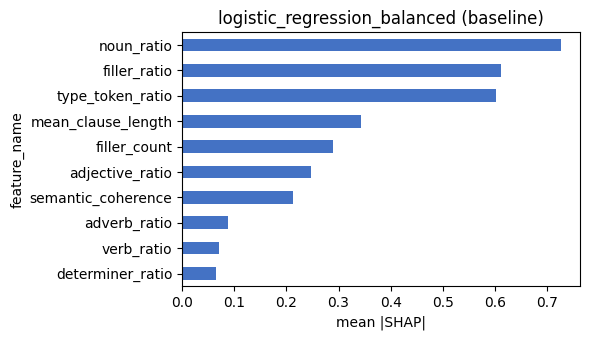

**baseline — random_forest** top |SHAP| (mean over participants)

,mean_abs_shap
feature_name,
filler_count,0.048441
type_token_ratio,0.033856
pronoun_ratio,0.031475
determiner_ratio,0.028122
adjective_ratio,0.026093
noun_ratio,0.025337
filler_ratio,0.019514
mean_clause_length,0.019014
adverb_ratio,0.014959


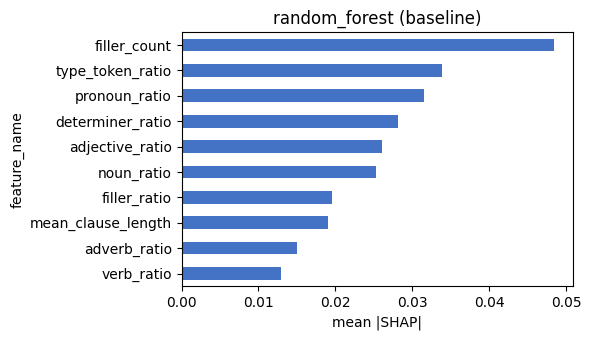

=== optimized ===


**optimized — logistic_regression_balanced** top |SHAP| (mean over participants)

,mean_abs_shap
feature_name,
noun_ratio,0.551236
type_token_ratio,0.460121
filler_ratio,0.391229
mean_clause_length,0.306671
determiner_ratio,0.000000
adjective_ratio,0.000000
adverb_ratio,0.000000
filler_count,0.000000
pronoun_ratio,0.000000


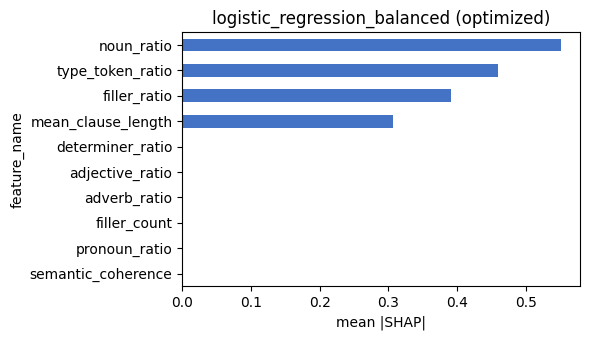

**optimized — random_forest** top |SHAP| (mean over participants)

,mean_abs_shap
feature_name,
filler_count,0.035205
type_token_ratio,0.026379
pronoun_ratio,0.026071
noun_ratio,0.019171
determiner_ratio,0.018796
adjective_ratio,0.015467
filler_ratio,0.015070
mean_clause_length,0.013261
adverb_ratio,0.013127


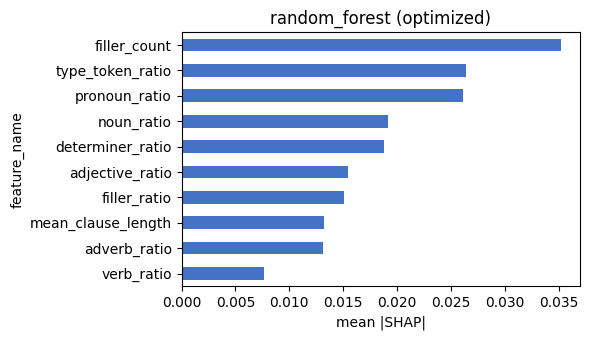

In [8]:
from pathlib import Path
import matplotlib.pyplot as plt

def top_shap_features(path: Path, model_name: str, top_k: int = 10):
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        return None
    sub = df[df["model"] == model_name]
    if sub.empty:
        return None
    g = (
        sub.groupby("feature_name")["shap_value"]
        .apply(lambda s: s.abs().mean())
        .sort_values(ascending=False)
        .head(top_k)
    )
    return g


for variant, path in [
    ("baseline", OUTPUT_DIR / "shap_values_baseline.csv"),
    ("optimized", OUTPUT_DIR / "shap_values_optimized.csv"),
]:
    print("===", variant, "===")
    for mname in ["logistic_regression_balanced", "random_forest"]:
        s = top_shap_features(path, mname)
        if s is None:
            print(f"No data for {mname} ({path.name} missing or empty)")
            continue
        display(Markdown(f"**{variant} — {mname}** top |SHAP| (mean over participants)"))
        display(s.to_frame("mean_abs_shap"))
        fig, ax = plt.subplots(figsize=(6, 3.5))
        s.iloc[::-1].plot(kind="barh", ax=ax, color="#4472c4")
        ax.set_xlabel("mean |SHAP|")
        ax.set_title(f"{mname} ({variant})")
        plt.tight_layout()
        plt.show()


---

## 10. Stability analysis

**Pipeline step:** `src/stability.py` aggregates:

- **CV folds:** refit on each training fold, SHAP on training subset, compare |SHAP| vectors across folds.
- **Bootstrap:** same idea on resampled data.
- **Baseline vs optimized:** Spearman / Jaccard between **global** mean |SHAP| profiles.

| Metric | High value means |
|--------|------------------|
| Spearman rank correlation | Similar **ranking** of features by importance. |
| Jaccard (top-5 overlap) | Similar **set of top drivers** across runs. |
| Mean CV of \|SHAP\| magnitudes | **Unstable attribution scale** across resamples (noisier explanations). |


### CV fold stability

metric,jaccard_top5_features,mean_cv_shap_magnitude_across_features,spearman_rank_importance
model,,,
logistic_regression,0.733333,0.552612,0.620909
logistic_regression_balanced,0.628571,0.488496,0.685455
random_forest,0.695238,0.244445,0.697273
random_forest_balanced,0.458333,0.301243,0.348182


### Bootstrap stability

metric,jaccard_top5_features,mean_cv_shap_magnitude_across_features,spearman_rank_importance
model,,,
logistic_regression,0.329970,0.599294,0.053420
logistic_regression_balanced,0.407748,0.649498,0.281818
random_forest,0.420899,0.418778,0.359827
random_forest_balanced,0.426531,0.446606,0.339048


### Baseline vs optimized

metric,jaccard_top5_baseline_vs_optimized,spearman_baseline_vs_optimized_global_importance
model,,
logistic_regression,0.666667,0.852868
logistic_regression_balanced,1.000000,0.852868
random_forest,0.666667,0.972727
random_forest_balanced,0.666667,0.827273
svm_rbf,0.428571,0.636364
svm_rbf_balanced,0.666667,0.918182


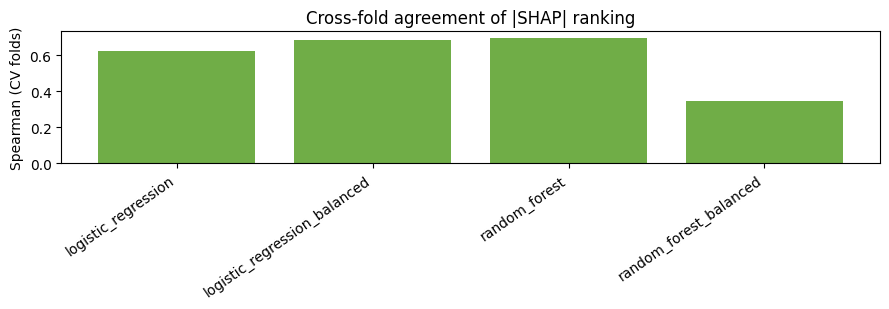

In [9]:
stab_path = OUTPUT_DIR / "stability_results.csv"
try:
    stab = pd.read_csv(stab_path)
except FileNotFoundError:
    stab = None
    print("Missing stability_results.csv")

if stab is not None:
    for title, pred in [
        ("CV fold stability", stab["scope"] == "cv_folds"),
        ("Bootstrap stability", stab["scope"] == "bootstrap"),
        ("Baseline vs optimized", stab["scope"] == "baseline_vs_optimized"),
    ]:
        display(Markdown(f"### {title}"))
        try:
            pivot = stab.loc[pred, ["metric", "model", "value"]].pivot_table(
                index="model", columns="metric", values="value"
            )
            display(pivot)
        except Exception as exc:
            print("Could not pivot table:", exc)
            display(stab.loc[pred])

    sub = stab[
        (stab["scope"] == "cv_folds")
        & (stab["metric"] == "spearman_rank_importance")
    ]
    if not sub.empty:
        fig, ax = plt.subplots(figsize=(9, 3.2))
        ax.bar(range(len(sub)), sub["value"].values, color="#70ad47")
        ax.set_xticks(range(len(sub)))
        ax.set_xticklabels(sub["model"].values, rotation=35, ha="right")
        ax.set_ylabel("Spearman (CV folds)")
        ax.set_title("Cross-fold agreement of |SHAP| ranking")
        plt.tight_layout()
        plt.show()


---

## 11. Performance–stability trade-off (figures)

These PNGs are written by `run_pipeline.py` → `src/visualization.py`. They support the thesis framing: **tuning may change AUROC, but do global explanations stay aligned?**


### `performance_comparison.png`

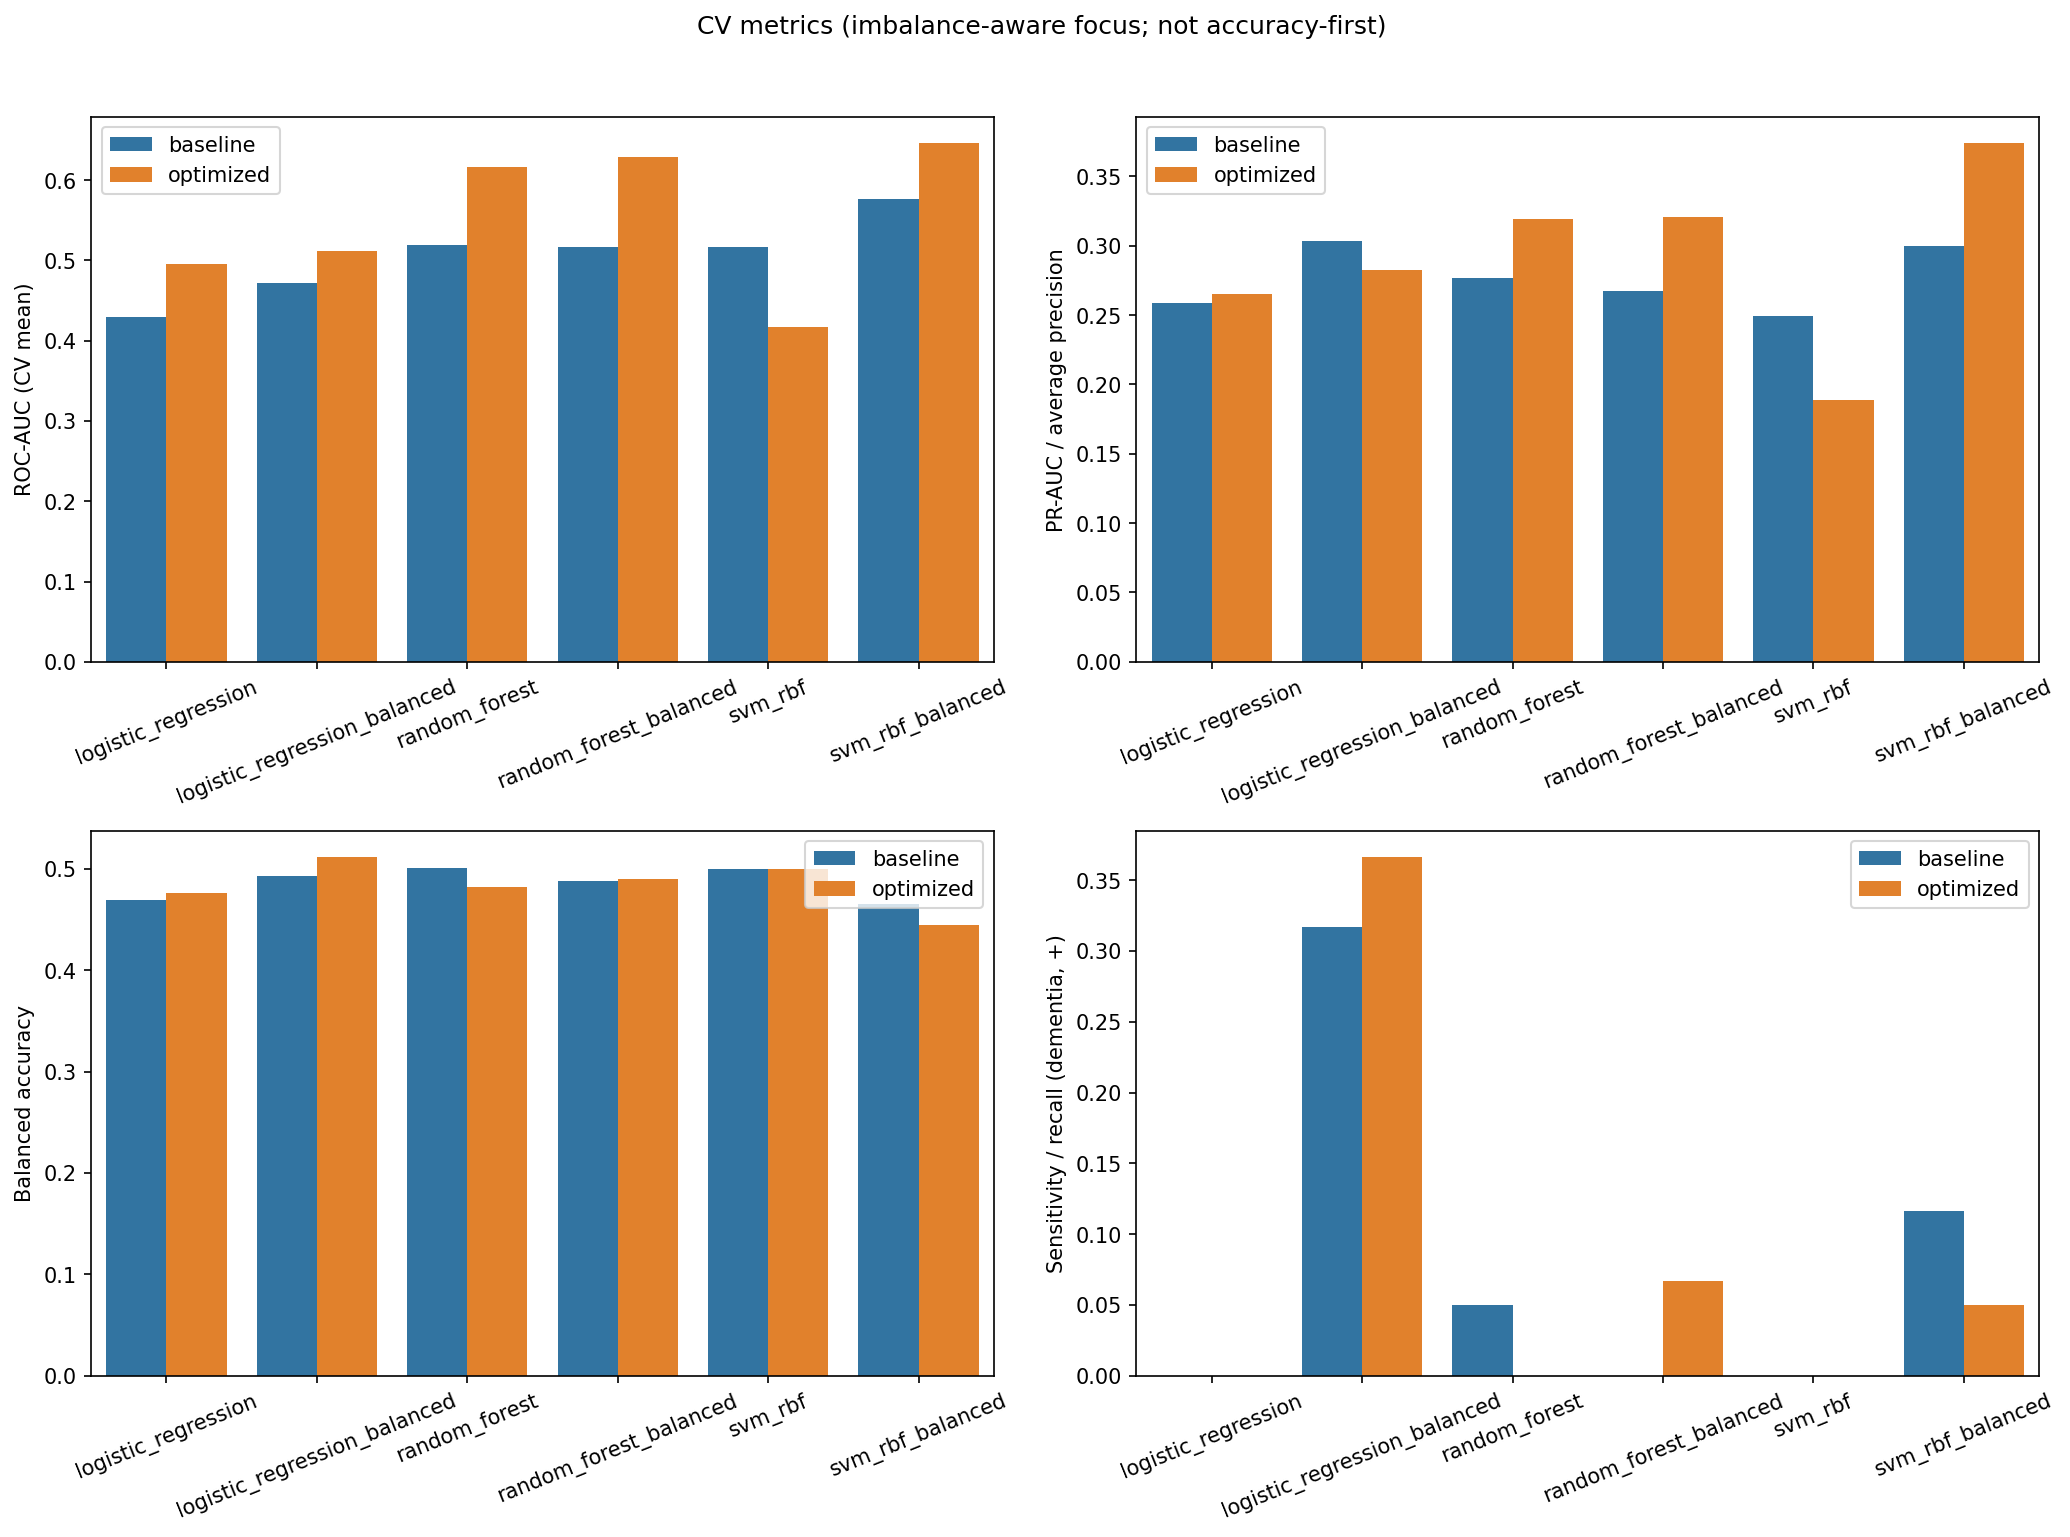

### `stability_comparison.png`

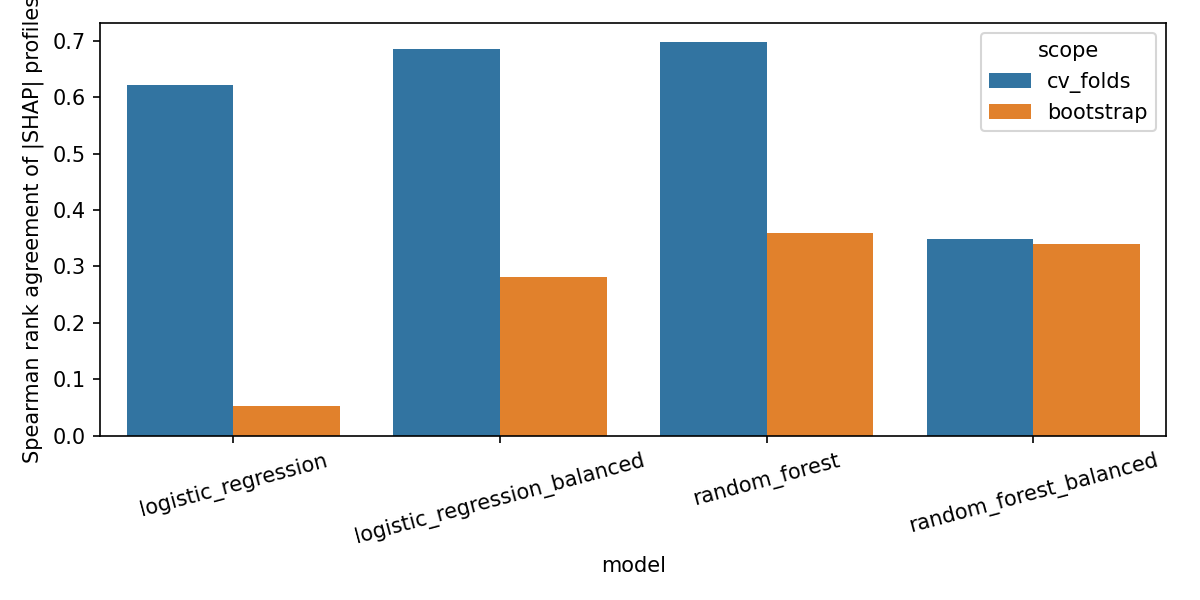

### `tradeoff_auroc_stability.png`

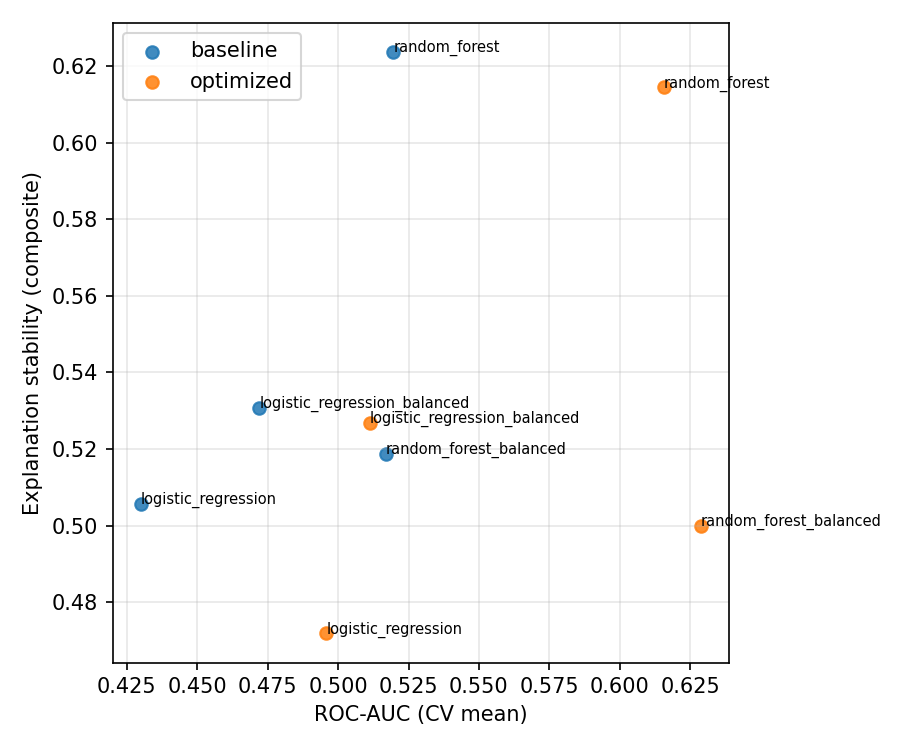

In [10]:
from IPython.display import Image as IPImage

for name in [
    "performance_comparison.png",
    "stability_comparison.png",
    "tradeoff_auroc_stability.png",
]:
    p = FIGURES_DIR / name
    if p.is_file():
        display(Markdown(f"### `{name}`"))
        display(IPImage(filename=str(p)))
    else:
        print("Missing:", p)


---

## 12. Supervisor summary

| Topic | Status |
|-------|--------|
| **Implemented** | Modular pipeline; imbalance metrics; balanced model variants; SHAP per family; stability + trade-off figures; CSV audit trail. |
| **What current numbers show** | Development-cohort behaviour (e.g. AUROC often modest; some models majority-class; balanced SVM may trade specificity for signal). **Interpret with your supervisor, not as clinical claims.** |
| **Why development-only** | Labels may come from augmented metadata; class ratio ≠ ADReSS challenge; feature set is research-grade, not a deployed product. |
| **Before final experiments** | Install official `participant_labels.csv`; align IDs to released transcripts; re-run pipeline; lock random seeds; report challenge-consistent metrics in the thesis body. |

---

**Next step for you:** run `python run_pipeline.py` after any code/data change, then **Restart kernel & run all** in this notebook to refresh tables and figures.
